# Data Splitting Strategy: Train/Test Protocol
Amazon Electronics Reviews — Helpfulness Prediction Pipeline

Author: Sanath | Module: WM9B7 AIDL | April 2026

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background')

In [2]:
df = pd.read_parquet('../data/processed/s03_filter.parquet')
print(f"Dataset: {df.shape[0]:,} records x {df.shape[1]} columns")
print(f"\nRating distribution:\n{df['rating'].value_counts().sort_index()}")

Dataset: 99,627 records x 17 columns

Rating distribution:
rating
1    22799
2     7315
3     8053
4    12914
5    48546
Name: count, dtype: int64


## Why 80/20?

For N=99,627, even 20% test = ~19,900 records. 70/30 wastes ~10K extra on testing. 90/10 risks undersampling rare review types. **80/20 is the consensus for large datasets** (Hastie et al., 2009).

Key considerations:
- **70/30**: Reduces training power for large datasets; wastes test capacity
- **75/25**: Middle ground, but less commonly standardized
- **80/20**: Industry standard; balances training power with test robustness
- **85/15**: Risk of sparse test set for minority classes
- **90/10**: Dangerous for datasets with rare subgroups; test set becomes too small

In [3]:
splits = {'70/30': 0.30, '75/25': 0.25, '80/20': 0.20, '85/15': 0.15, '90/10': 0.10}
print(f"{'Split':>8} {'Train':>12} {'Test':>12} {'Test per rating★':>20}")
print("-" * 55)
for name, test_pct in splits.items():
    n_test = int(len(df) * test_pct)
    n_train = len(df) - n_test
    per_rating = n_test // 5  # rough estimate
    print(f"{name:>8} {n_train:>12,} {n_test:>12,} {per_rating:>20,}")
print(f"\n✅ Recommended: 80/20 → {int(len(df)*0.8):,} train / {int(len(df)*0.2):,} test")

   Split        Train         Test     Test per rating★
-------------------------------------------------------
   70/30       69,739       29,888                5,977
   75/25       74,721       24,906                4,981
   80/20       79,702       19,925                3,985
   85/15       84,683       14,944                2,988
   90/10       89,665        9,962                1,992

✅ Recommended: 80/20 → 79,701 train / 19,925 test


## Stratification: Preserve Label Distribution

We stratify on `rating` to preserve the 1-5 star distribution in both train and test splits. This ensures:
- Balanced representation of all rating classes
- No evaluation bias from skewed label distributions
- Model robustness across all review sentiment levels

**Critical for imbalanced data**: If 80% of reviews are 5-stars, random split might give train 79% and test 82%. Stratification keeps both at ~80%.

## Temporal Analysis: Is There Drift?

Check if review characteristics change significantly over time. If so, temporal split might be more realistic than random split.

**Key metrics to monitor**:
- Review volume trends
- Helpfulness score distribution over time
- Review length evolution
- Verification rate changes

Yearly statistics:
      count  mean_helpful  median_helpful  mean_length  verified_pct
year                                                                
2000     11        36.000            15.0     1050.182         0.000
2001     11         9.273             5.0      871.091         0.273
2002     12         6.083             3.5      896.917         0.250
2003     33        10.182             4.0     1002.788         0.273
2004     53        12.604             5.0      997.547         0.358
2005    173        18.364             5.0      934.827         0.301
2006    364        11.110             5.0      864.720         0.376
2007    727        11.717             2.0      793.083         0.462
2008    858         9.354             2.0      902.315         0.543
2009   1014        13.308             2.0      923.878         0.629
2010   1362        10.570             2.0      987.504         0.777
2011   2500        10.812             2.0      971.490         0.785
2012   3402    

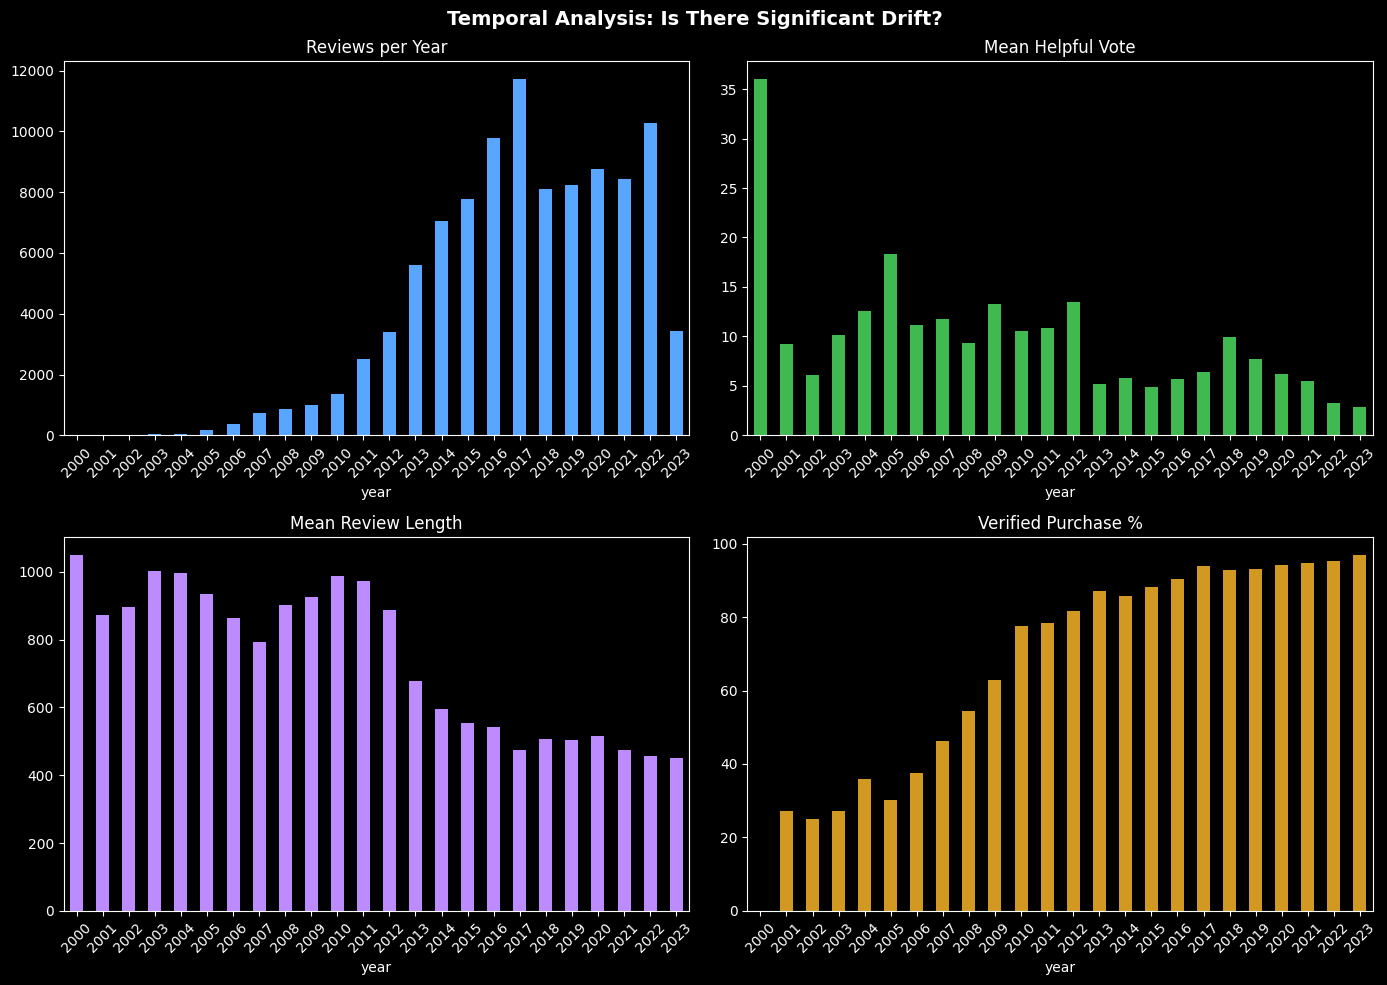

In [4]:
# s03_filter.parquet has no absolute timestamp - reconstruct year from days_since_first_review,
# whose reference date is clean_reviews.parquet's timestamp.min() (the same anchor 02_feature_engineering.ipynb used)
FIRST_REVIEW_DATE = pd.Timestamp("1996-11-18 16:58:00")
df['year'] = (FIRST_REVIEW_DATE + pd.to_timedelta(df['days_since_first_review'], unit='D')).dt.year
yearly = df.groupby('year').agg(
    count=('helpful_vote', 'size'),
    mean_helpful=('helpful_vote', 'mean'),
    median_helpful=('helpful_vote', 'median'),
    mean_length=('review_length', 'mean'),
    verified_pct=('is_verified', 'mean')
).round(3)

print("Yearly statistics:")
print(yearly.to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
yearly['count'].plot(kind='bar', ax=axes[0,0], color='#58A6FF', title='Reviews per Year')
yearly['mean_helpful'].plot(kind='bar', ax=axes[0,1], color='#3FB950', title='Mean Helpful Vote')
yearly['mean_length'].plot(kind='bar', ax=axes[1,0], color='#BC8CFF', title='Mean Review Length')
(yearly['verified_pct']*100).plot(kind='bar', ax=axes[1,1], color='#D29922', title='Verified Purchase %')
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Temporal Analysis: Is There Significant Drift?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Leakage Prevention Checklist

**CRITICAL**: Before any model evaluation, verify you have NOT committed any of these leakage violations:

- [ ] **Never fit preprocessing (scaler, encoder) on combined train+test data**
  - ✅ Fit on X_train only, transform X_test with those parameters

- [ ] **Never use test set information when engineering features**
  - ✅ All feature creation must happen on train set first

- [ ] **Never stratify on target variable directly**
  - ✅ We stratify on `rating` (a feature), not `helpful_vote` (the target)

- [ ] **Never shuffle and split within cross-validation folds**
  - ✅ Use StratifiedKFold with fixed random_state

- [ ] **Never use global statistics (mean, median, std) from full dataset in features**
  - ✅ Compute statistics from training set only

- [ ] **Never perform model selection on test set**
  - ✅ Use cross-validation on training set for hyperparameter tuning

- [ ] **Never pick features based on test set correlations**
  - ✅ Feature selection must occur during training phase only

- [ ] **Never peek at test predictions before final report**
  - ✅ Hold test predictions until after model is finalized

## Team Standard Configuration

### ✅ REQUIRED: Use this exact split for all models

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,           # 80% train / 20% test
    random_state=42,          # reproducibility
    stratify=df['rating']     # preserve rating distribution
)
```

**All team members must use this configuration:**
- Sanath
- Lithika
- Takuya
- Arjun

This ensures:
1. **Reproducibility**: Same random_state = same splits across all notebooks
2. **Comparability**: All models evaluated on identical test sets
3. **Consistency**: Single source of truth for model performance metrics